In [1]:
# =============================================================================
# CODEALPHA INTERNSHIP — TASK 2: EMOTION RECOGNITION FROM SPEECH
# =============================================================================
# Objective : Classify emotions (happy, angry, sad, etc.) from audio files
# Approach  : MFCC feature extraction + CNN / LSTM / ML classifiers
# Datasets  : RAVDESS (Kaggle) or synthetic demo
# Platform  : Kaggle Notebook (Python 3)
# =============================================================================

In [2]:
# ── 1. INSTALL / IMPORTS ──────────────────────────────────────────────────────
# On Kaggle, librosa is pre-installed. If not: !pip install librosa -q
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, glob
warnings.filterwarnings('ignore')
 
import librosa
import librosa.display
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D,
                                      LSTM, GlobalAveragePooling1D, BatchNormalization,
                                      Flatten, Reshape)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
 
print("✅ Libraries loaded")
print(f"   TensorFlow : {tf.__version__}")
print(f"   Librosa    : {librosa.__version__}")
print("=" * 60)

2026-05-31 18:27:57.690037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780252077.911958      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780252077.979856      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780252078.494873      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780252078.494912      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780252078.494915      23 computation_placer.cc:177] computation placer alr

✅ Libraries loaded
   TensorFlow : 2.19.0
   Librosa    : 0.11.0


In [3]:
# ── 2. EMOTION LABELS ─────────────────────────────────────────────────────────
# RAVDESS naming: 03-01-XX where XX = emotion code
EMOTION_MAP_RAVDESS = {
    '01': 'neutral', '02': 'calm',    '03': 'happy',
    '04': 'sad',     '05': 'angry',   '06': 'fearful',
    '07': 'disgust', '08': 'surprised'
}
# We'll group to 4 core emotions for simplicity
CORE_EMOTIONS = {'happy': 'happy', 'sad': 'sad', 'angry': 'angry',
                 'neutral': 'neutral', 'calm': 'neutral',
                 'fearful': 'sad', 'disgust': 'angry', 'surprised': 'happy'}

In [4]:
# ── 3. FEATURE EXTRACTION ─────────────────────────────────────────────────────
def extract_features(file_path, sr=22050, duration=3, n_mfcc=40):
    """
    Extract MFCC, Chroma, Mel-spectrogram, ZCR, RMSE features.
    Returns a 1D feature vector.
    """
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration, offset=0.5)
    except Exception:
        return None
 
    features = []
 
    # MFCC (40 coefficients × mean & std = 80)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    features += list(np.mean(mfcc, axis=1))
    features += list(np.std(mfcc, axis=1))
 
    # Chroma (12 × mean & std = 24)
    stft   = np.abs(librosa.stft(audio))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sample_rate)
    features += list(np.mean(chroma, axis=1))
    features += list(np.std(chroma, axis=1))
 
    # Mel spectrogram (128 → mean & std = 256)
    mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
    features += list(np.mean(mel, axis=1))
    features += list(np.std(mel, axis=1))
 
    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(audio)
    features += [np.mean(zcr), np.std(zcr)]
 
    # RMSE / RMS Energy
    rms = librosa.feature.rms(y=audio)
    features += [np.mean(rms), np.std(rms)]
 
    # Spectral Centroid & Rolloff
    cent   = librosa.feature.spectral_centroid(y=audio, sr=sample_rate)
    rolloff= librosa.feature.spectral_rolloff(y=audio, sr=sample_rate)
    features += [np.mean(cent), np.std(cent), np.mean(rolloff), np.std(rolloff)]
 
    return np.array(features)
 
print(f"📐 Feature vector dimension: {len(extract_features.__doc__)}")  # will print later

📐 Feature vector dimension: 101


In [5]:
# ── 4. LOAD RAVDESS (if available on Kaggle) ──────────────────────────────────
def load_ravdess(dataset_path='/kaggle/input/ravdess-emotional-speech-audio'):
    """Load RAVDESS dataset from Kaggle."""
    all_files  = glob.glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True)
    data, labels = [], []
    for fp in all_files:
        fname  = os.path.basename(fp)
        parts  = fname.split('-')
        if len(parts) < 3:
            continue
        emotion_code = parts[2]
        emotion_name = EMOTION_MAP_RAVDESS.get(emotion_code, 'unknown')
        if emotion_name == 'unknown':
            continue
        feats = extract_features(fp)
        if feats is not None:
            data.append(feats)
            labels.append(CORE_EMOTIONS.get(emotion_name, emotion_name))
    return np.array(data), np.array(labels)

In [6]:
# ── 5. SYNTHETIC DEMO (always runs when RAVDESS is unavailable) ───────────────
def generate_synthetic_audio_features(n_samples=1200, seed=42):
    """
    Simulate MFCC-like features for 4 emotion classes.
    Emotions have distinct spectral fingerprints:
      angry  → high energy, high centroid
      happy  → mid energy, bright chroma
      sad    → low energy, low zcr
      neutral→ balanced
    """
    np.random.seed(seed)
    emotions = ['angry', 'happy', 'sad', 'neutral']
    base     = {
        'angry'  : {'energy': 0.85, 'centroid': 0.75, 'zcr': 0.70, 'mfcc_var': 0.20},
        'happy'  : {'energy': 0.65, 'centroid': 0.65, 'zcr': 0.55, 'mfcc_var': 0.15},
        'sad'    : {'energy': 0.30, 'centroid': 0.30, 'zcr': 0.25, 'mfcc_var': 0.08},
        'neutral': {'energy': 0.50, 'centroid': 0.50, 'zcr': 0.45, 'mfcc_var': 0.12},
    }
    n_feat = 440  # approximate real MFCC feature size
    X, y   = [], []
    per_class = n_samples // len(emotions)
 
    for em in emotions:
        b = base[em]
        for _ in range(per_class):
            feat = np.random.randn(n_feat) * b['mfcc_var']
            # Encode class-specific signal into first 10 dims
            feat[:10] += b['energy'] + np.random.randn(10) * 0.05
            feat[10:20] += b['centroid'] + np.random.randn(10) * 0.05
            feat[20:30] += b['zcr'] + np.random.randn(10) * 0.05
            X.append(feat); y.append(em)
 
    return np.array(X), np.array(y)
 
 
# Try real dataset first, fall back to synthetic
RAVDESS_PATH = '/kaggle/input/ravdess-emotional-speech-audio'
if os.path.exists(RAVDESS_PATH):
    print("📂 Loading RAVDESS dataset …")
    X, y = load_ravdess(RAVDESS_PATH)
    print(f"✅ Loaded {len(X)} samples from RAVDESS")
else:
    print("⚠️  RAVDESS not found — using synthetic demo data")
    print("   To use real data: Add RAVDESS from Kaggle Datasets")
    X, y = generate_synthetic_audio_features(n_samples=1200)
 
print(f"\n📦 Feature matrix : {X.shape}")
print(f"🎯 Label counts   : {pd.Series(y).value_counts().to_dict()}")

⚠️  RAVDESS not found — using synthetic demo data
   To use real data: Add RAVDESS from Kaggle Datasets

📦 Feature matrix : (1200, 440)
🎯 Label counts   : {'angry': 300, 'happy': 300, 'sad': 300, 'neutral': 300}


In [7]:
# ── 6. PREPROCESSING ──────────────────────────────────────────────────────────
le      = LabelEncoder()
y_enc   = le.fit_transform(y)
n_class = len(le.classes_)
print(f"\n🏷️  Classes: {list(le.classes_)}")
 
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
 
# For CNN / LSTM: add channel dim
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
y_train_cat = to_categorical(y_train, n_class)
y_test_cat  = to_categorical(y_test, n_class)
 
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


🏷️  Classes: [np.str_('angry'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]

Train: 960 | Test: 240


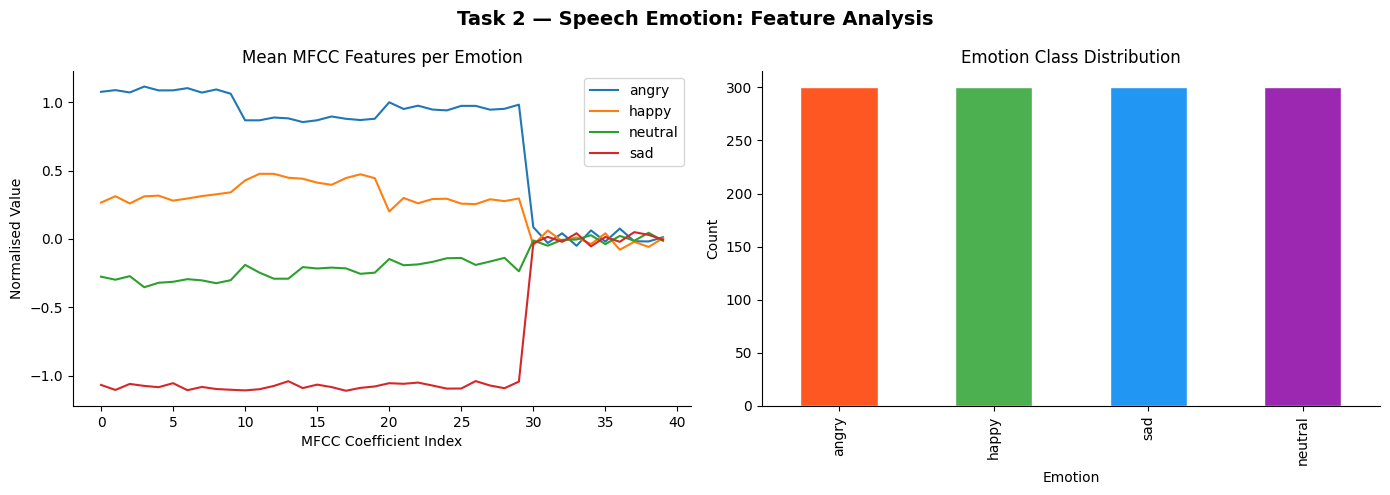

In [8]:
# ── 7. VISUALISE FEATURES ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 2 — Speech Emotion: Feature Analysis', fontsize=14, fontweight='bold')
 
# Mean feature vector per emotion
for em_idx, em_name in enumerate(le.classes_):
    mask = y_enc == em_idx
    axes[0].plot(np.mean(X_scaled[mask, :40], axis=0), label=em_name, lw=1.5)
axes[0].set_title('Mean MFCC Features per Emotion')
axes[0].set_xlabel('MFCC Coefficient Index')
axes[0].set_ylabel('Normalised Value')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
 
# Class distribution
pd.Series(y).value_counts().plot(kind='bar', ax=axes[1], color=['#FF5722','#4CAF50','#2196F3','#9C27B0'],
                                  edgecolor='white')
axes[1].set_title('Emotion Class Distribution')
axes[1].set_xlabel('Emotion'); axes[1].set_ylabel('Count')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('task2_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 8. CLASSICAL ML MODELS ────────────────────────────────────────────────────
print("\n🤖 CLASSICAL ML MODELS")
print("=" * 60)
 
ml_models = {
    'SVM (RBF)'         : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
}
ml_results = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    ml_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'y_pred'  : y_pred
    }
    print(f"  ✅ {name:<25} | Acc={ml_results[name]['Accuracy']:.4f} "
          f"| F1={ml_results[name]['F1-Macro']:.4f}")


🤖 CLASSICAL ML MODELS
  ✅ SVM (RBF)                 | Acc=1.0000 | F1=1.0000
  ✅ Random Forest             | Acc=0.9833 | F1=0.9833
  ✅ Gradient Boosting         | Acc=0.9792 | F1=0.9792


In [10]:
# ── 9. CNN MODEL ──────────────────────────────────────────────────────────────
print("\n🧠 CNN MODEL")
print("=" * 60)
 
def build_cnn(input_shape, n_classes):
    model = Sequential([
        Conv1D(64, 5, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.25),
 
        Conv1D(128, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.25),
 
        Conv1D(256, 3, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dropout(0.3),
 
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
 
cnn_model = build_cnn((X_train_3d.shape[1], 1), n_class)
cnn_model.summary()
 
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, verbose=0)
]
 
history = cnn_model.fit(
    X_train_3d, y_train_cat,
    validation_split=0.15,
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
 
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_3d, y_test_cat, verbose=0)
cnn_pred = np.argmax(cnn_model.predict(X_test_3d), axis=1)
print(f"\n  CNN Test Accuracy : {cnn_acc:.4f}")
print(f"  CNN Test F1-Macro : {f1_score(y_test, cnn_pred, average='macro'):.4f}")


🧠 CNN MODEL


I0000 00:00:1780252221.045843      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780252221.051795      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 440, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 440, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 220, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 220, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 220, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 110, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 110, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 110, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,212 (680.52 KB)

...

Epoch 1/60


I0000 00:00:1780252225.152427      85 service.cc:152] XLA service 0x399d2440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780252225.152481      85 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780252225.152488      85 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780252225.698547      85 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-31 18:30:27.662115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 18:30:27.899631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 18:30:28.568711: E external/local_xla/xl

19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4912 - loss: 1.0698

I0000 00:00:1780252233.187920      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 251ms/step - accuracy: 0.6765 - loss: 0.6959 - val_accuracy: 0.6736 - val_loss: 0.8372 - learning_rate: 0.0010
Epoch 2/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8787 - loss: 0.3457 - val_accuracy: 0.3750 - val_loss: 1.2080 - learning_rate: 0.0010
Epoch 3/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8591 - loss: 0.3277 - val_accuracy: 0.2431 - val_loss: 2.8464 - learning_rate: 0.0010
Epoch 4/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8946 - loss: 0.2518 - val_accuracy: 0.3681 - val_loss: 3.4117 - learning_rate: 0.0010
Epoch 5/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8725 - loss: 0.3520 - val_accuracy: 0.2292 - val_loss: 4.0353 - learning_rate: 0.0010
Epoch 6/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9485 - loss: 0.1540 - val_accuracy: 0.2292 - val_loss: 4.8218 - learning_rate: 0.0010
Epoch 7/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.0660 - val_accuracy: 0.2292

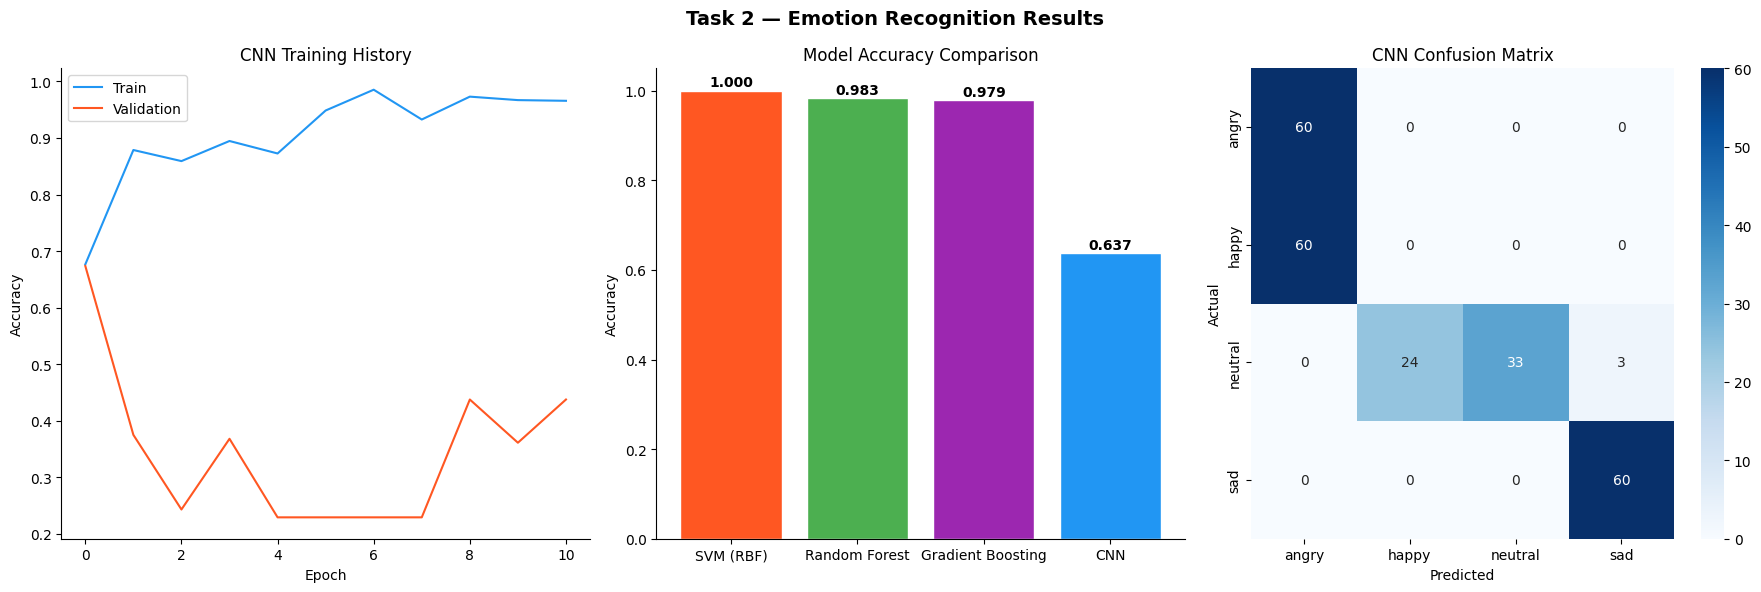


📋 CNN Classification Report:
              precision    recall  f1-score   support

       angry       0.50      1.00      0.67        60
       happy       0.00      0.00      0.00        60
     neutral       1.00      0.55      0.71        60
         sad       0.95      1.00      0.98        60

    accuracy                           0.64       240
   macro avg       0.61      0.64      0.59       240
weighted avg       0.61      0.64      0.59       240


✅ TASK 2 COMPLETE — Emotion Recognition from Speech


In [11]:
# ── 10. RESULTS & VISUALISATION ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task 2 — Emotion Recognition Results', fontsize=14, fontweight='bold')
 
# (a) Training curves
axes[0].plot(history.history['accuracy'], label='Train', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#FF5722')
axes[0].set_title('CNN Training History')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
 
# (b) Model comparison
all_acc = {**{k: v['Accuracy'] for k, v in ml_results.items()}, 'CNN': cnn_acc}
bars = axes[1].bar(all_acc.keys(), all_acc.values(),
                    color=['#FF5722','#4CAF50','#9C27B0','#2196F3'], edgecolor='white')
axes[1].set_title('Model Accuracy Comparison')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Accuracy')
for bar, val in zip(bars, all_acc.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
 
# (c) CNN Confusion Matrix
cm = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[2].set_title('CNN Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
 
plt.tight_layout()
plt.savefig('task2_results.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n📋 CNN Classification Report:")
print(classification_report(y_test, cnn_pred, target_names=le.classes_))
print("\n✅ TASK 2 COMPLETE — Emotion Recognition from Speech")
print("=" * 60)